In [20]:
import pandas as pd

email_batch_1 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch1.csv')
email_batch_2 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch2.csv')
email_batch_3 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch3.csv')
email_batch_4 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch4.csv')
email_batch_5 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch5.csv')
email_batch_6 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch6.csv')
email_batch_7 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch7.csv')
email_batch_8 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch8.csv')
email_batch_9 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch9.csv')
email_batch_10 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch10.csv')
email_batch_11 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/Generated_Email_Dataset.csv')
email_batch_12 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/strictly_unique_final_email_dataset_10k.csv')
email_batch_13 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/balanced_final_email_dataset_10k.csv')
email_batch_14 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/high_quality_balanced_email_dataset_10k.csv')
email_batch_15 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/sample_300_realistic_unique_emails.csv')
email_batch_16 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/realistic_synthetic_email_dataset_5k.csv')
email_batch_17 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/final_email_category_balanced_kg.csv')

email_data = pd.concat([email_batch_1, email_batch_2, email_batch_3, email_batch_4, email_batch_5, email_batch_6, email_batch_7, email_batch_8, email_batch_9, email_batch_10, email_batch_11, email_batch_12, email_batch_13, email_batch_14, email_batch_15, email_batch_16, email_batch_17], ignore_index=True)
email_data.columns

Index(['EmailID', 'From', 'To', 'DateTime', 'Subject', 'Message', 'Category',
       'Cleaned_Subject', 'Cleaned_Message'],
      dtype='object')

In [21]:
category_corrections = {
    "IT Alerts & System Notitfications Email": "IT Alerts & System Notifications Email",
    "Spma Email": "Spam Email",
    "Meeting & Schedule": "Meeting & Schedule Email",
    "IT Alerts & System Notifications": "IT Alerts & System Notifications Email",
    "Spam": "Spam Email",
    "Legal & Contractual": "Legal & Contractual Email",
    "Meeting & Scheduling": "Meeting & Schedule Email",
    "Personal Communication & Purely Personal": "Personal Email",
    "General Business Communication": "Work or Business Email",
    "Finance & Transactions": "Finance & Transaction Email",
    "Internal Policies & HR Updates": "Internal Policies & HR Updates Email",
    "IT Alerts & System Notifications": "IT Alerts & System Notifications Email"
}

email_data['Category'] = email_data['Category'].replace(category_corrections)
email_data['Category'].value_counts()

Category
Work or Business Email                    68192
Finance & Transaction Email               47965
Personal Email                            41357
Meeting & Schedule Email                  34035
Internal Policies & HR Updates Email      32332
Legal & Contractual Email                 32314
Spam Email                                32314
IT Alerts & System Notifications Email    32280
Promotions or Marketing Email             12324
Social Media Email                        12313
Utilities Bill Email                      12283
Name: count, dtype: int64

In [22]:
# Check for duplicates based on Subject + Message
duplicate_subject_msg = email_data[email_data.duplicated(subset=['Subject', 'Message'])]
print(f"📧 Duplicates based on Subject + Message: {duplicate_subject_msg.shape[0]}")

📧 Duplicates based on Subject + Message: 113082


In [23]:
email_data = email_data.drop_duplicates(subset=['Subject', 'Message'], keep='first')

print(f"✅ New dataset shape after removing duplicates: {email_data.shape}")

✅ New dataset shape after removing duplicates: (244627, 9)


In [24]:
import re
def remove_duplicate_sentences(text):
    if not isinstance(text, str):
        return ""
    sentences = re.split(r'(?<=[.!?])\s+', text)
    seen = set()
    cleaned = []
    for s in sentences:
        norm = re.sub(r'[.!?]', '', s.strip().lower())
        if norm not in seen:
            seen.add(norm)
            cleaned.append(s.strip())
    return ' '.join(cleaned)

email_data['Cleaned_Message'] = email_data['Message'].apply(remove_duplicate_sentences)

In [25]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Optional: Download once
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_email_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Fix encoding artifacts
    text = re.sub(r'=20', ' ', text)
    text = re.sub(r'=09', ' ', text)
    text = re.sub(r'=3D', '=', text)
    text = re.sub(r'=\s?', '', text)

    # 2. Normalize spacing and remove extra line breaks
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # 3. Remove obvious garbage characters but retain useful punctuation
    text = re.sub(r'[^\w\s.,!?%&$@/-]', '', text)

    # 4. Remove URLs and email addresses
    text = re.sub(r'\b(?:http|https|www)\S*', '', text)
    text = re.sub(r'\b\S+@\S+\b', '', text)

    # 5. Lowercase (standard for NLP)
    text = text.lower()

    # 6. Remove very long strings of digits or nonsensical code-like text
    text = re.sub(r'\b\d{8,}\b', '', text)

    return text.strip()

def clean_subject_line(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'^(FW:|RE:|Fwd:|Re:|\[.*?\])', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

def tokenize_and_filter(text):
    # Tokenize and remove stopwords (optional depending on task)
    tokens = word_tokenize(text)
    filtered = [token for token in tokens if token not in stop_words]
    return " ".join(filtered)

# Example usage:
email_data['Cleaned_Subject'] = email_data['Subject'].apply(clean_subject_line)
email_data['Cleaned_Message'] = email_data['Cleaned_Message'].apply(clean_email_text)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
email_data

# Subject Light Cleaning

In [26]:
def clean_subject_line(text):
    if not isinstance(text, str):
        return ""

    # Remove email reply/forward prefixes
    text = re.sub(r'^(FW:|RE:|Fwd:|Re:|\[.*?\])', '', text, flags=re.IGNORECASE)

    # Remove emojis
    emoji_pattern = re.compile(
        "[" 
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE
    )
    text = emoji_pattern.sub(r'', text)

    # Normalize spacing
    return re.sub(r'\s+', ' ', text).strip().lower()
email_data['Cleaned_Subject'] = email_data['Cleaned_Subject'].apply(clean_subject_line)

In [8]:
email_data.to_csv('cleaned_category_email_dataset_pretrained_model.csv', index=False)

# Message Cleaning

In [28]:
import re

def ml_clean_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Remove emails and URLs
    text = re.sub(r'\b\S+@\S+\b', '', text)                      # email addresses
    text = re.sub(r'\b(?:http|https|www)\S*\b', '', text)        # URLs

    # 2. Remove emojis
    emoji_pattern = re.compile(
        "[" 
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE
    )
    text = emoji_pattern.sub(r'', text)

    # 3. Remove unwanted symbols (keep .,!?%/- for meaning)
    text = re.sub(r'[^a-zA-Z0-9\s.,!?%/:-]', '', text)

    # 4. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Lowercase
    return text.lower()

email_data['Cleaned_Message'] = email_data['Cleaned_Message'].apply(clean_message_text)

In [ ]:
import re

def remove_duplicate_sentences(text, mode='normal'):
    """
    Remove duplicate sentences from a text.
    Modes:
    - 'basic' : Only exact match (with punctuation)
    - 'normal': Normalize by lowercasing and removing trailing punctuation
    - 'strict': Normalize by lowercasing and removing all punctuation
    """
    if not isinstance(text, str):
        return ""
    
    sentences = re.split(r'(?<=[.!?])\s+', text)
    seen = set()
    cleaned = []

    for s in sentences:
        raw = s.strip()

        if mode == 'basic':
            normalized = raw
        elif mode == 'normal':
            normalized = re.sub(r'[.!?]+$', '', raw.lower())
        elif mode == 'strict':
            normalized = re.sub(r'[.!?]', '', raw.lower())
        else:
            raise ValueError("Mode must be 'basic', 'normal', or 'strict'.")

        if normalized not in seen:
            seen.add(normalized)
            cleaned.append(raw)

    return ' '.join(cleaned)

email_data['Cleaned_Message'] = email_data['Cleaned_Message'].apply(lambda x: remove_duplicate_sentences(x, mode='normal'))


In [33]:
# Check for duplicates based on Subject + Message
duplicate_subject_msg = email_data[email_data.duplicated(subset=['Cleaned_Subject', 'Cleaned_Message'])]
print(f"📧 Duplicates based on Subject + Message: {duplicate_subject_msg.shape[0]}")

📧 Duplicates based on Subject + Message: 755


In [34]:
email_data = email_data.drop_duplicates(subset=['Cleaned_Subject', 'Cleaned_Message'], keep='first')

print(f"✅ New dataset shape after removing duplicates: {email_data.shape}")

✅ New dataset shape after removing duplicates: (243872, 9)


In [ ]:
email_data

In [19]:
email_data.to_csv('test_cleaned_category_email_dataset_machine_learning_model.csv', index=False)

In [8]:
syn_email = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/Categorization/test_cleaned_category_email_dataset_machine_learning_model.csv')
origin_email = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/email_batch_9_labeled_qwen2.5.csv')

email_data = pd.concat([syn_email, origin_email], ignore_index=True)
email_data.columns

C:\Users\User\AppData\Local\Temp\ipykernel_22304\624477937.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  syn_email = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/Categorization/test_cleaned_category_email_dataset_machine_learning_model.csv')


Index(['EmailID', 'From', 'To', 'DateTime', 'Subject', 'Message', 'Category',
       'Cleaned_Message', 'Cleaned_Subject'],
      dtype='object')

In [ ]:
email_data

In [35]:
email_data.to_csv('test_cleaned_category_email_dataset_machine_learning_model.csv', index=False)

# Data Exploration

In [37]:
import pandas as pd

email_data = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/Categorization/cleaned_category_email_dataset_machine_learning_model.csv')

In [38]:
email_data['Combined_Text'] = email_data['Cleaned_Subject'].fillna('') + ' ' + email_data['Cleaned_Message'].fillna('')

In [ ]:
email_data

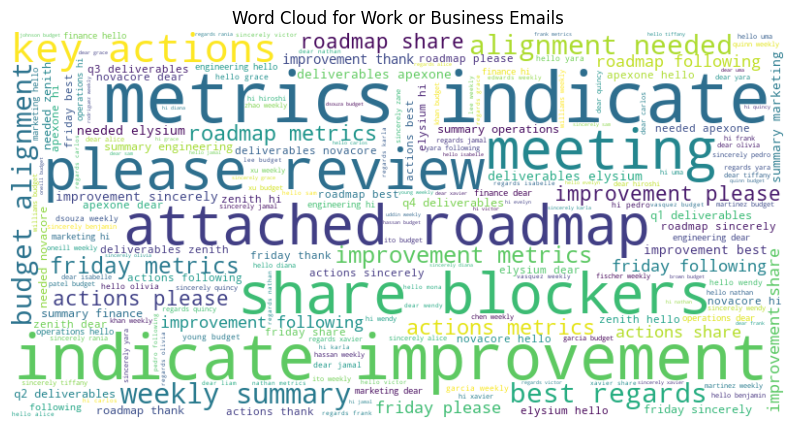

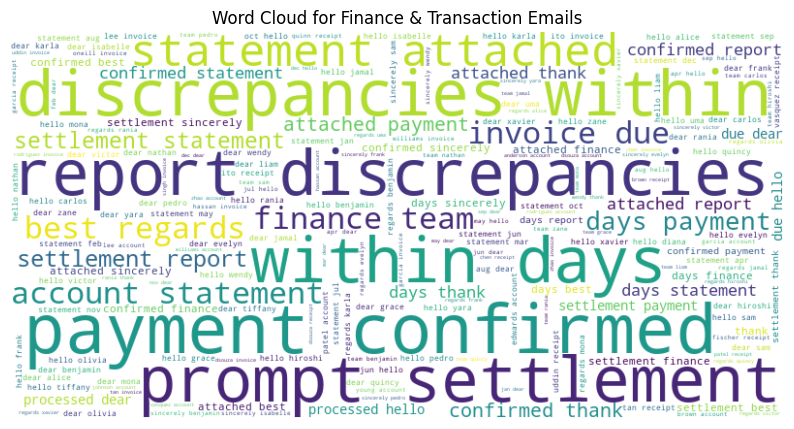

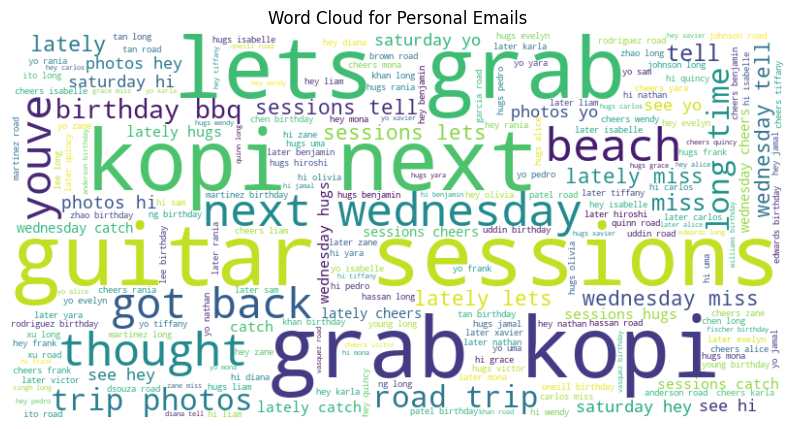

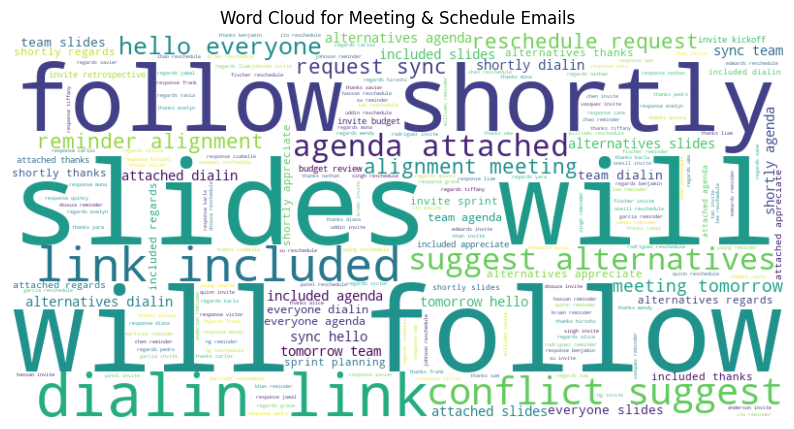

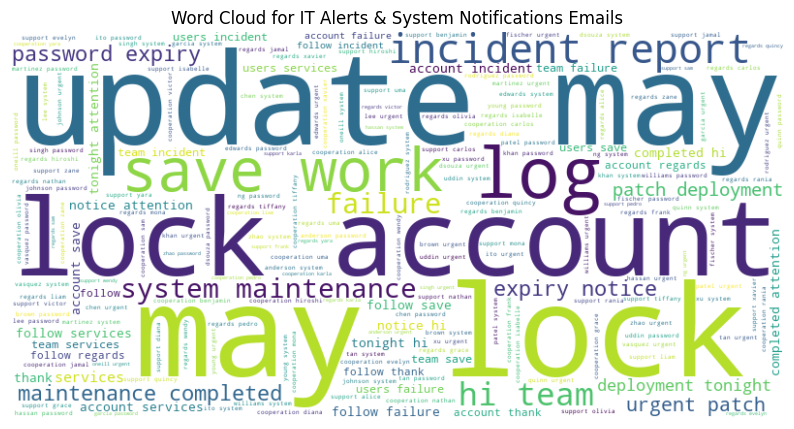

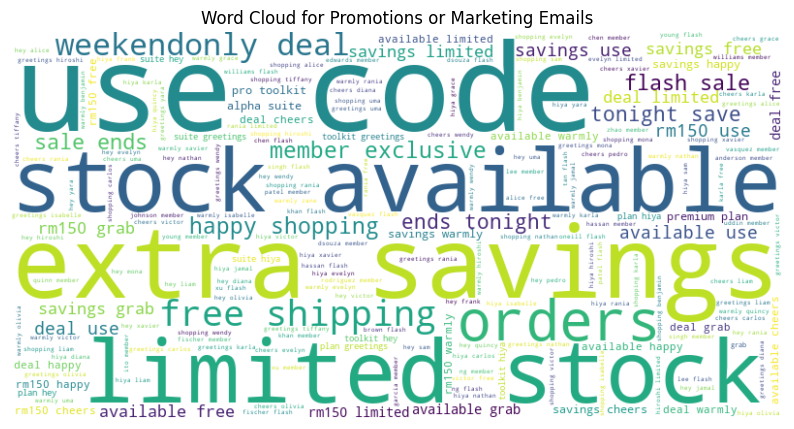

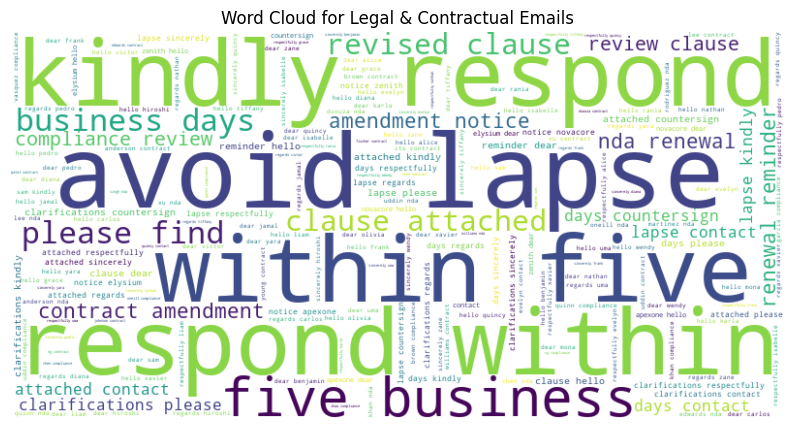

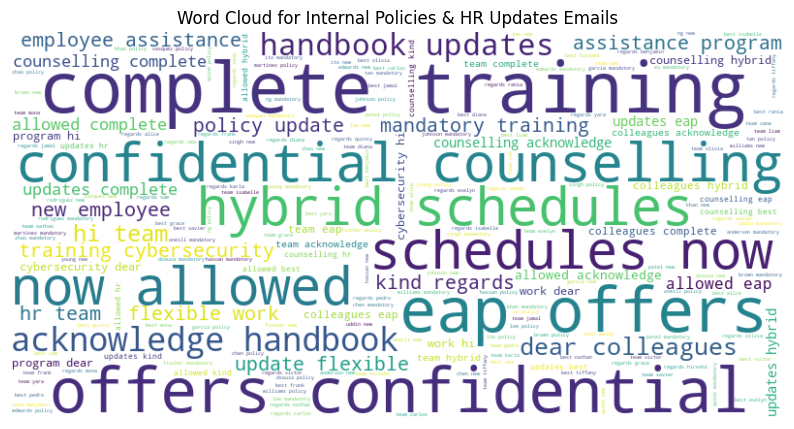

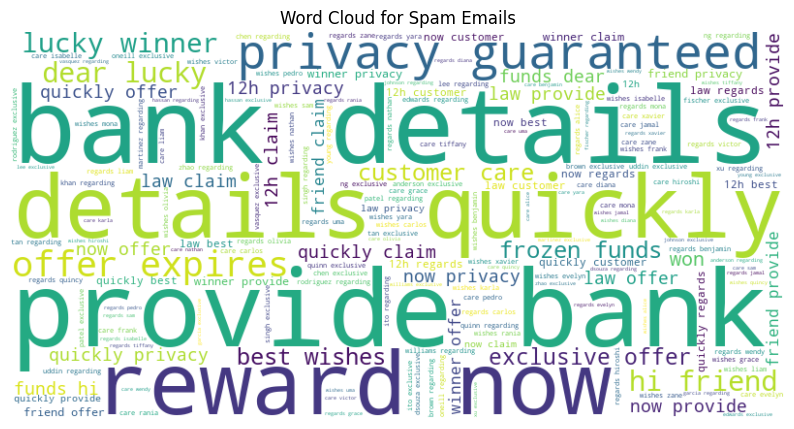

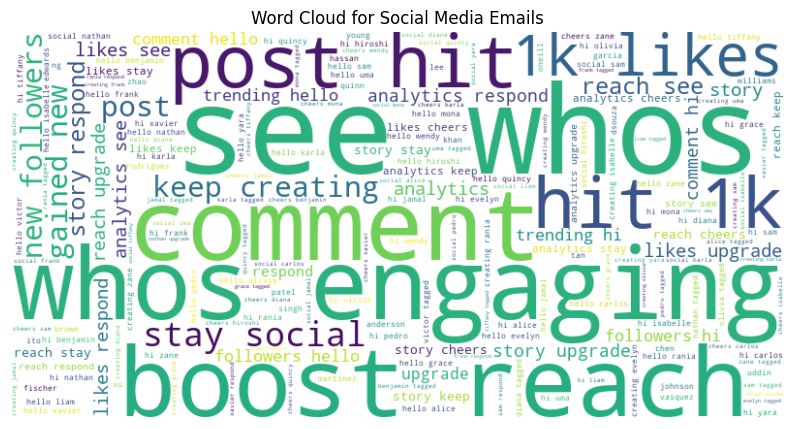

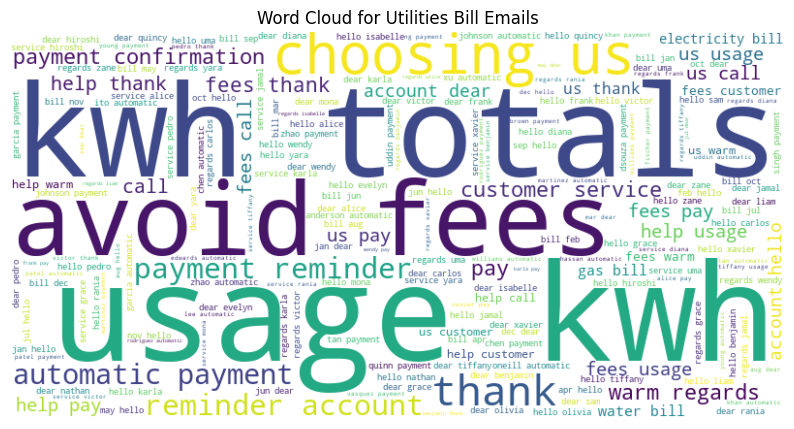

In [34]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

## Work or Business Email
business_emails = email_data[email_data['Category'] == 'Work or Business Email']
text = " ".join(str(msg) for msg in business_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Work or Business Emails")
plt.show()

## Finance & Transaction Email
finance_emails = email_data[email_data['Category'] == 'Finance & Transaction Email']
text = " ".join(str(msg) for msg in finance_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Finance & Transaction Emails")
plt.show()

## Personal Email
personal_emails = email_data[email_data['Category'] == 'Personal Email']
text = " ".join(str(msg) for msg in personal_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Personal Emails")
plt.show()

## Meeting & Schedule
meeting_emails = email_data[email_data['Category'] == 'Meeting & Schedule Email']
text = " ".join(str(msg) for msg in meeting_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Meeting & Schedule Emails")
plt.show()

## IT Alerts & System Notitfications Email
IT_emails = email_data[email_data['Category'] == 'IT Alerts & System Notitfications Email']
text = " ".join(str(msg) for msg in IT_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for IT Alerts & System Notifications Emails")
plt.show()

## Promotions or Marketing Email
promo_emails = email_data[email_data['Category'] == 'Promotions or Marketing Email']
text = " ".join(str(msg) for msg in promo_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Promotions or Marketing Emails")
plt.show()

## Legal & Contractual Email
legal_emails = email_data[email_data['Category'] == 'Legal & Contractual Email']
text = " ".join(str(msg) for msg in legal_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Legal & Contractual Emails")
plt.show()

## Internal Policies & HR Updates Email
hr_emails = email_data[email_data['Category'] == 'Internal Policies & HR Updates Email']
text = " ".join(str(msg) for msg in hr_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Internal Policies & HR Updates Emails")
plt.show()

## Spma Email
spam_emails = email_data[email_data['Category'] == 'Spam Email']
text = " ".join(str(msg) for msg in spam_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Spam Emails")
plt.show()

## Social Media Email
social_emails = email_data[email_data['Category'] == 'Social Media Email']
text = " ".join(str(msg) for msg in social_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Social Media Emails")
plt.show()

## Utilities Bill Email
utilities_emails = email_data[email_data['Category'] == 'Utilities Bill Email']
text = " ".join(str(msg) for msg in utilities_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Utilities Bill Emails")
plt.show()

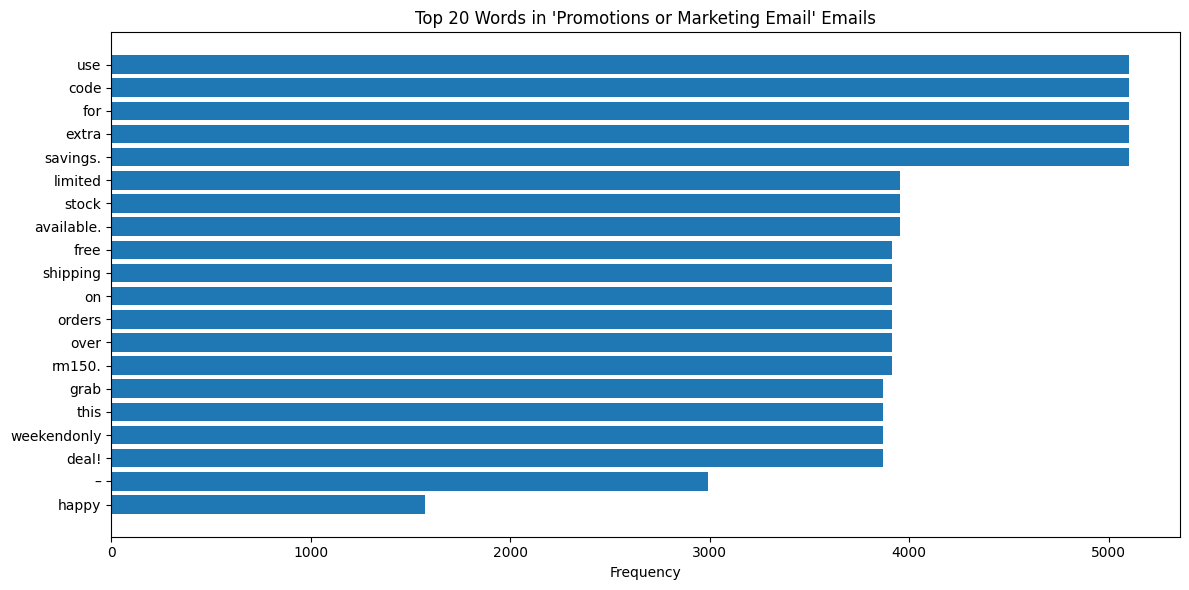

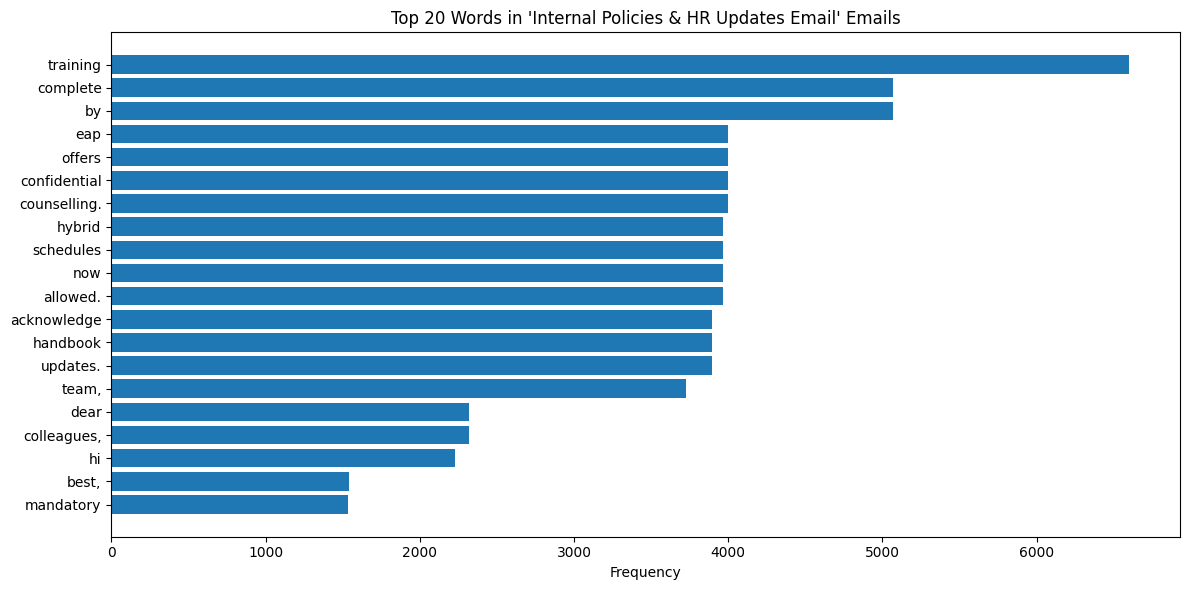

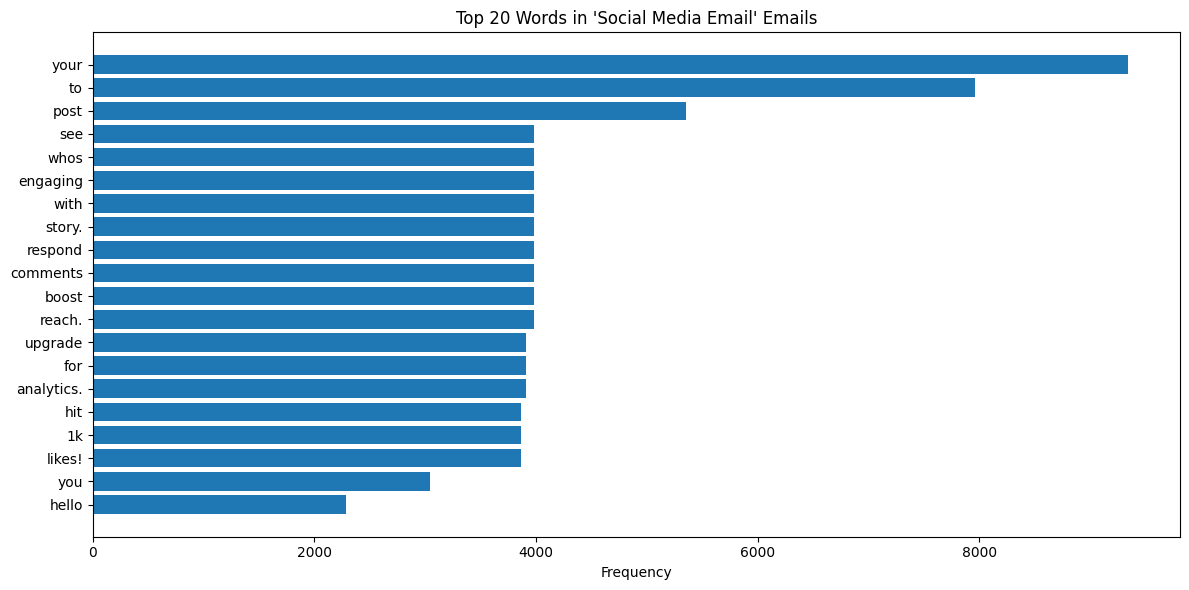

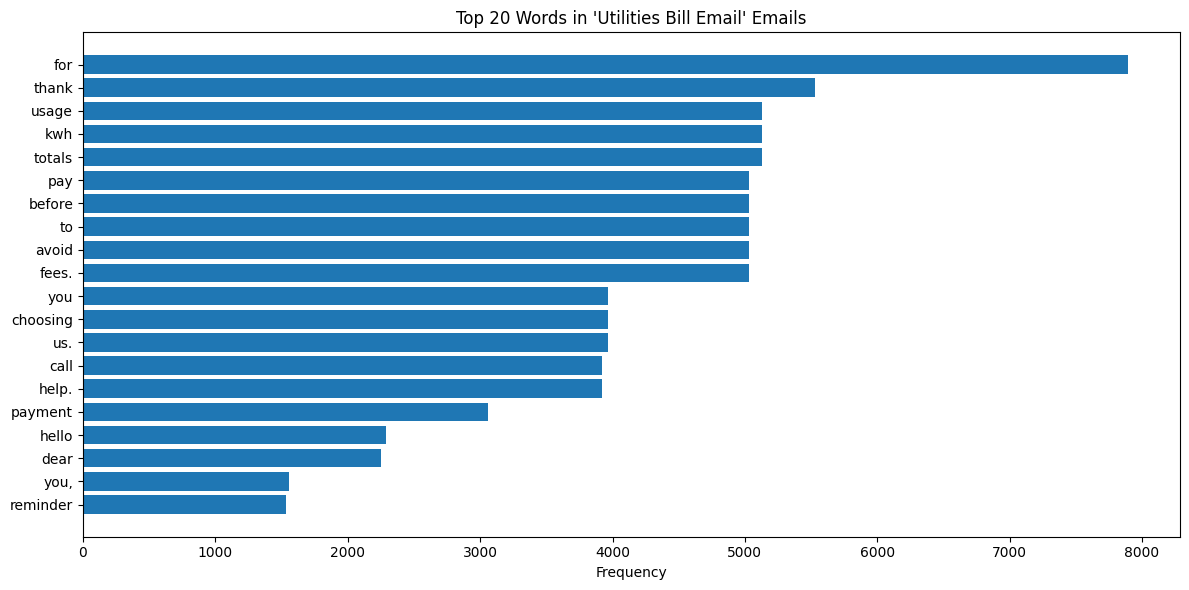

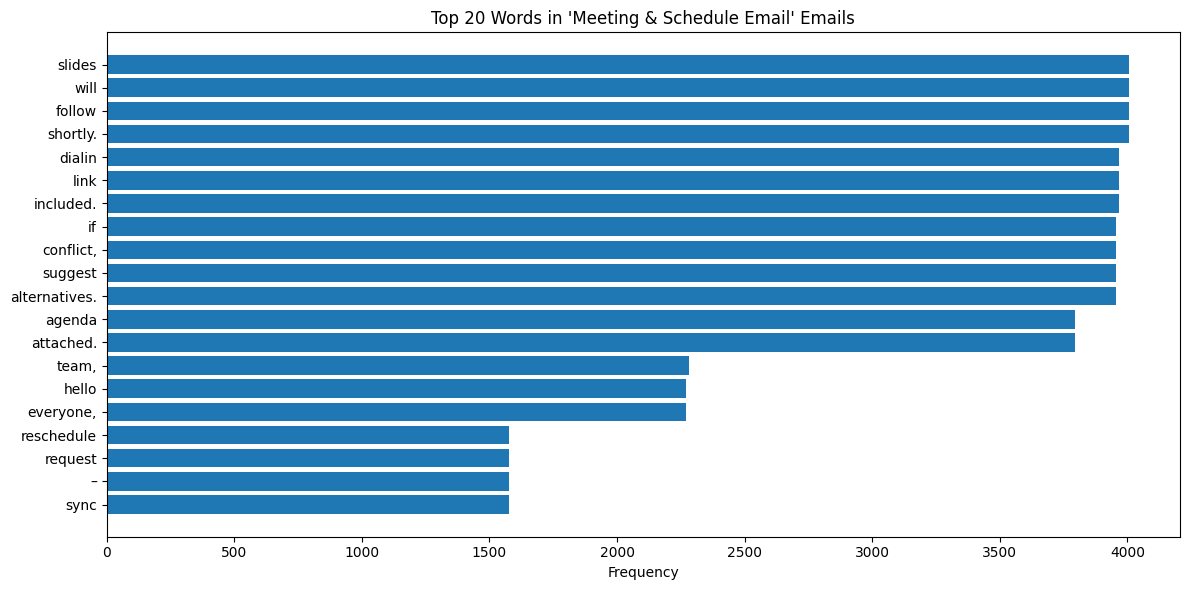

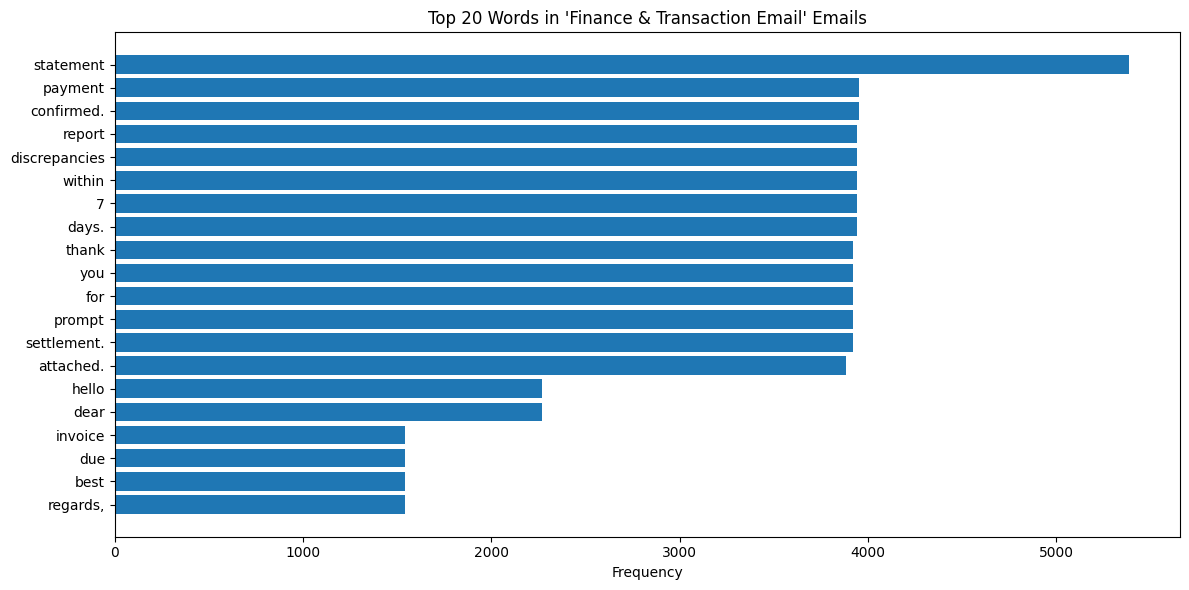

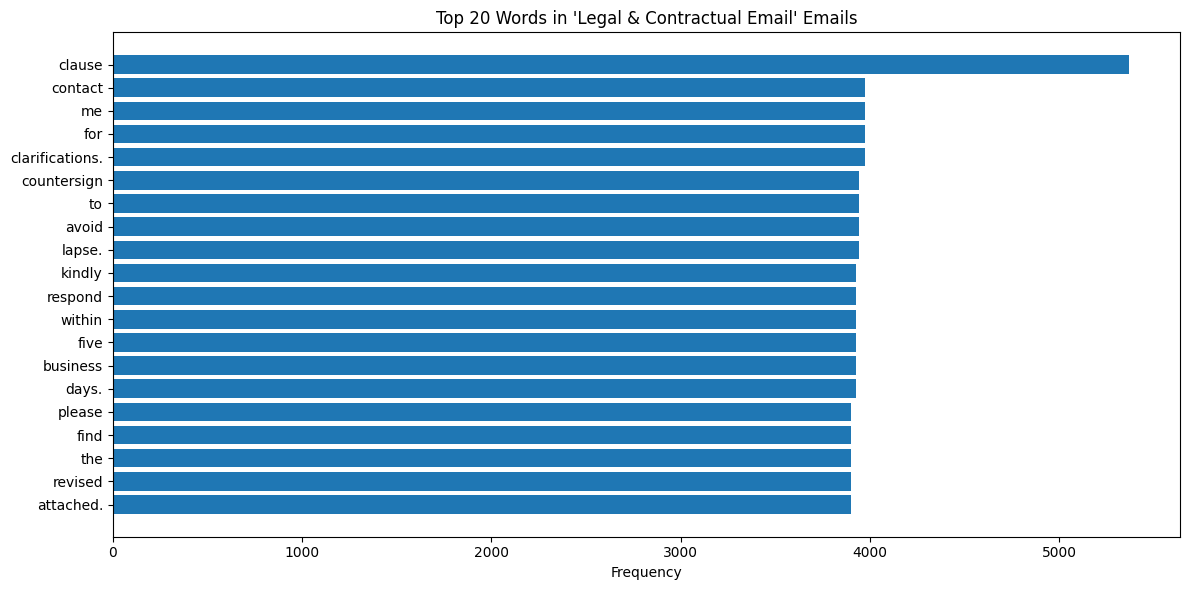

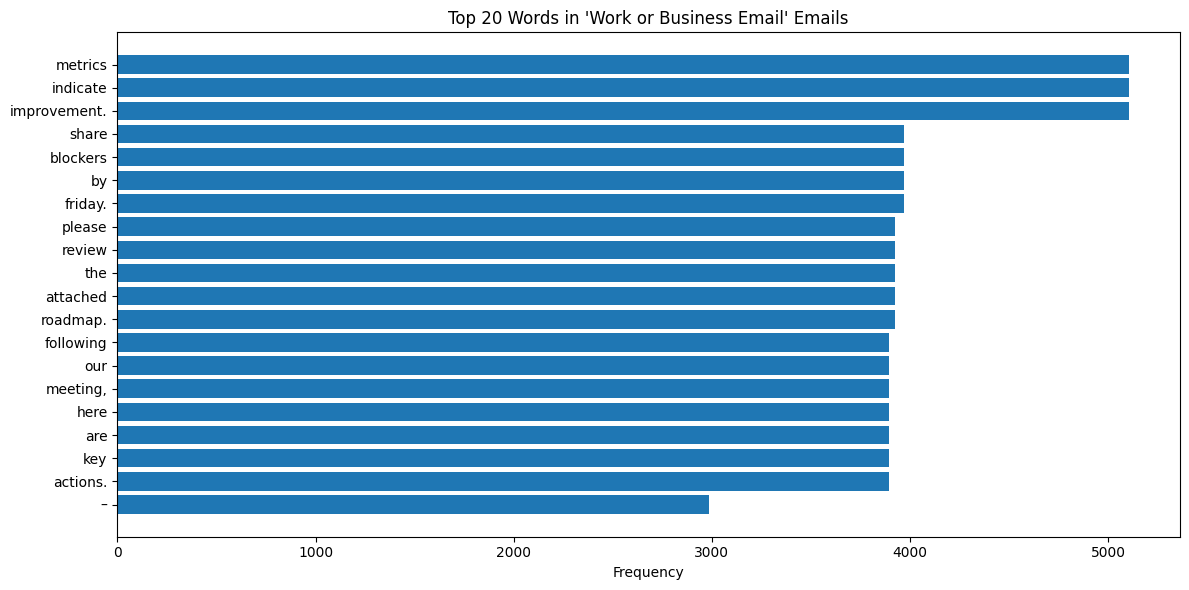

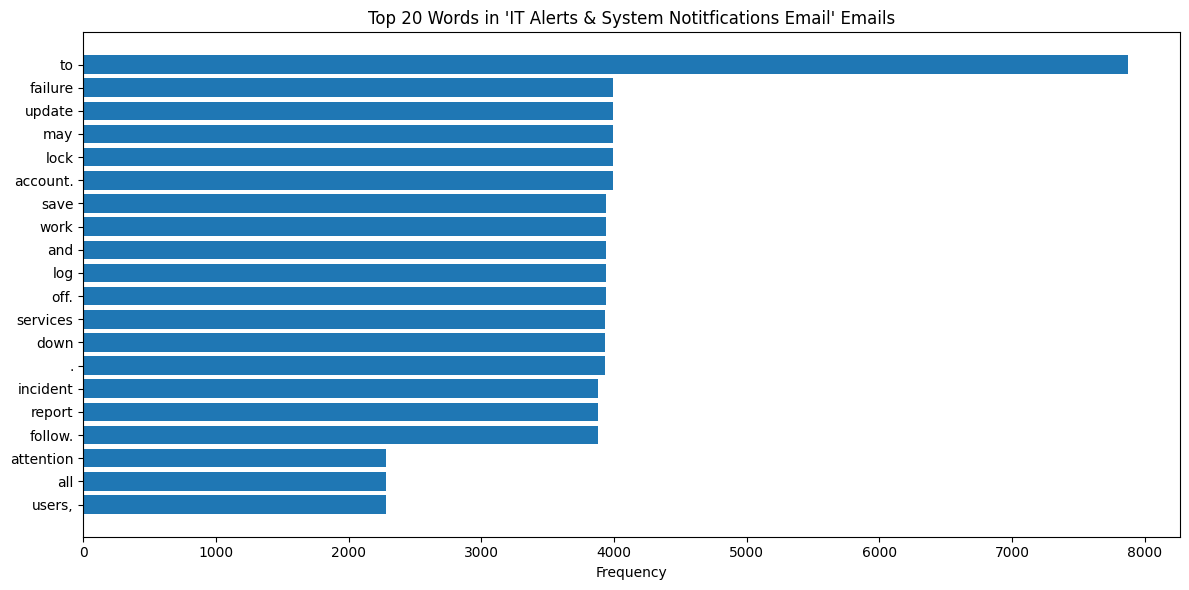

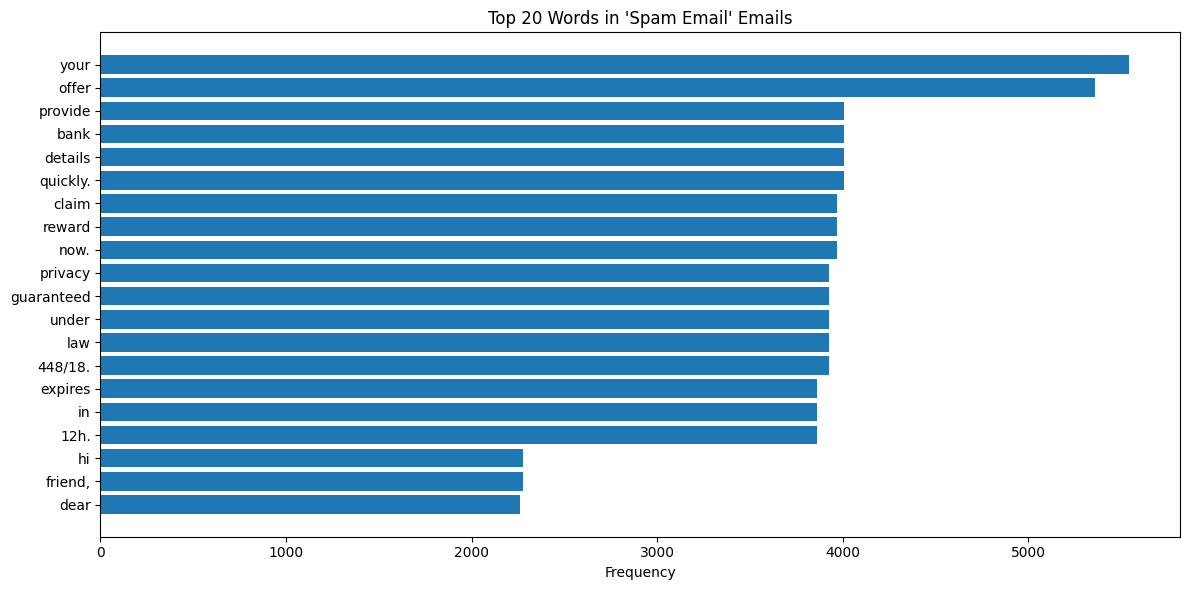

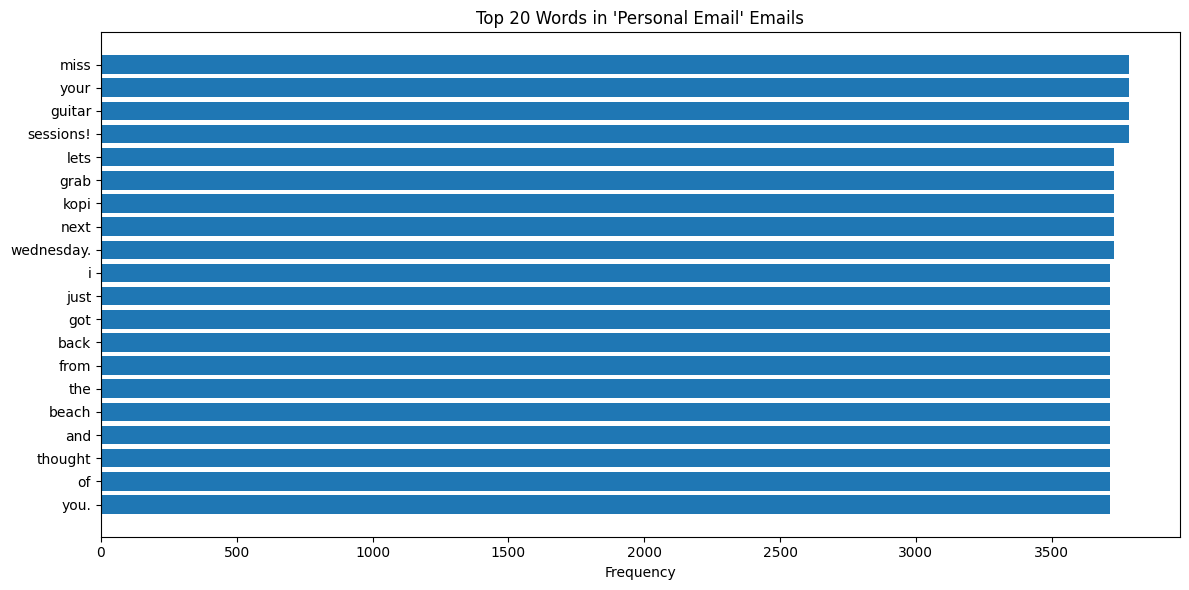

In [35]:
from collections import Counter
import matplotlib.pyplot as plt

categories = email_data['Category'].unique()

for category in categories:
    category_emails = email_data[email_data['Category'] == category]
    
    text = " ".join(str(msg) for msg in category_emails['Combined_Text'].dropna())
    words = text.split()
    
    word_freq = Counter(words)
    top_words = word_freq.most_common(20)
    
    if not top_words:
        continue

    labels, values = zip(*top_words)

    plt.figure(figsize=(12, 6))
    plt.barh(labels, values)
    plt.xlabel("Frequency")
    plt.title(f"Top 20 Words in '{category}' Emails")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()